# AI/ML Ignition Program — Hands-on ML Regression Project
## Bengaluru House Price Prediction using Linear Regression

In today’s session, we build a complete beginner-friendly Machine Learning regression project.

**Goal:** predict house prices using property details such as location, square feet area, number of bathrooms, number of bedrooms, and area type.

We will use **only Linear Regression**. We will not use hyperparameter tuning, GridSearchCV, Ridge, Lasso, Random Forest, or any advanced model.

At the end, we will save the trained model as a **pickle file** so it can be reused later without training again.

> Keep `Bengaluru_House_Data.csv` in the same folder as this notebook before running the cells.

## Step 1 — Import Required Libraries

### What this cell does
This cell imports the Python libraries we need for the project.

### Why we do this
**Technical reason:**
- `pandas` helps us load and work with table data.
- `numpy` helps us do numerical operations.
- `matplotlib` helps us draw graphs.
- `sklearn` gives us the Linear Regression model and tools to split data.
- `pickle` helps us save the trained model.

**Machine Learning reason:**
Before building a model, we need tools for data loading, data cleaning, visualization, model training, testing, and saving the model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams["figure.figsize"] = (12, 6)

## Step 2 — Load the Dataset

### What this cell does
This cell loads the house price dataset from a CSV file into a Pandas DataFrame called `df`.

### Why we do this
**Technical reason:**
A CSV file cannot be directly used for analysis until we load it into Python. Pandas converts the CSV into a table-like structure.

**Machine Learning reason:**
The dataset is the raw material for the ML model. Each row represents one house/property record, and the model will learn patterns from these records.

In [2]:
df = pd.read_csv("Bengaluru_House_Data.csv")
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


## Step 3 — Understand the Dataset Shape

### What this cell does
This cell shows how many rows and columns are in the dataset.

### Why we do this
**Technical reason:**
`shape` quickly tells us the size of the dataset.

**Machine Learning reason:**
More rows usually give the model more examples to learn from. More columns mean more features, but not every column will be useful.

In [3]:
print("Number of rows and columns:", df.shape)

Number of rows and columns: (13320, 9)


## Step 4 — Check Column Names and Data Types

### What this cell does
This cell displays column names, data types, and missing value counts.

### Why we do this
**Technical reason:**
We need to know which columns are numerical and which columns are text/categorical.

**Machine Learning reason:**
ML models cannot directly understand most text values. Text columns such as `location` and `area_type` must be converted into numbers later.

In [4]:
df.info()
print("Column names:")
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB
Column names:
Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')


## Step 5 — View Basic Statistical Summary

### What this cell does
This cell shows summary statistics for numerical columns, such as mean, minimum, maximum, and standard deviation.

### Why we do this
**Technical reason:**
`describe()` helps us understand the numerical range of the dataset.

**Machine Learning reason:**
This helps us identify suspicious values and outliers. For example, very low square feet for many bedrooms may not be realistic.

In [5]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


## Step 6 — Visualize Numerical Columns

### What this cell does
This cell creates histograms for numerical columns.

### Why we do this
**Technical reason:**
Histograms show how values are distributed.

**Machine Learning reason:**
Before training, we should understand whether the data has unusual patterns or extreme values. Outliers can reduce model accuracy.

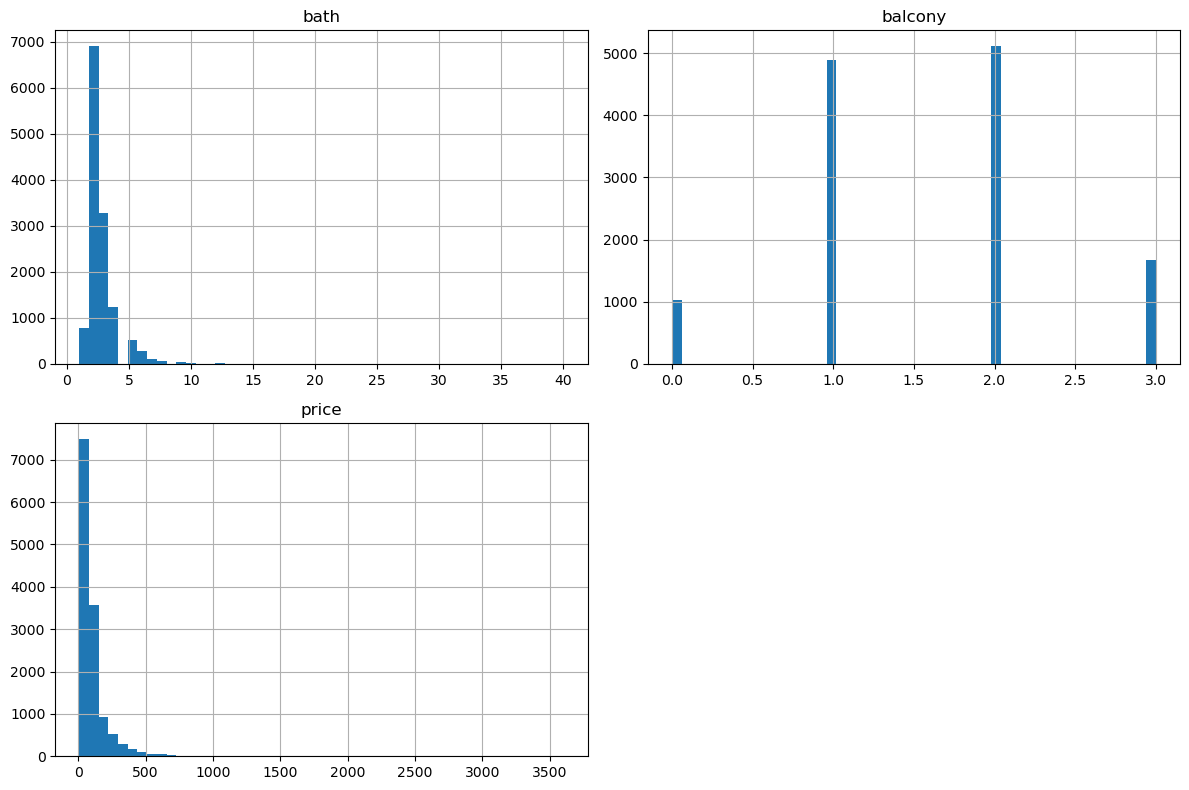

In [6]:
df.hist(bins=50, figsize=(12, 8))
plt.tight_layout()
plt.show()

## Step 7 — Drop Less Useful Columns

### What this cell does
This cell removes `society` and `availability`.

### Why we do this
**Technical reason:**
Some columns are not useful for this beginner Linear Regression model. `society` has many missing/unique values, and `availability` is not easy to use directly in this simple session.

**Machine Learning reason:**
Removing less useful columns keeps the model simpler and easier to understand.

In [7]:
df2 = df.drop(["society", "availability"], axis="columns")
df2.head()

,area_type,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Plot Area,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Built-up Area,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Super built-up Area,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Super built-up Area,Kothanur,2 BHK,1200,2.0,1.0,51.00


## Step 8 — Check Missing Values

### What this cell does
This cell checks how many missing values exist in each column.

### Why we do this
**Technical reason:**
Missing values can cause errors during model training.

**Machine Learning reason:**
The model needs complete input values. We must either fill missing values or remove rows with missing values.

In [8]:
df2.isnull().sum()

area_type       0
location        1
size           16
total_sqft      0
bath           73
balcony       609
price           0
dtype: int64

## Step 9 — Fill Missing Balcony Values

### What this cell does
This cell fills missing values in the `balcony` column with the value `4`.

### Why we do this
**Technical reason:**
This avoids missing values in the balcony column.

**Machine Learning reason:**
A model cannot train properly with missing values. Here we use a simple fixed value to keep the lesson beginner-friendly.

In [9]:
df2["balcony"] = df2["balcony"].fillna(4)
df2.isnull().sum()

area_type      0
location       1
size          16
total_sqft     0
bath          73
balcony        0
price          0
dtype: int64

## Step 10 — Remove Remaining Missing Rows

### What this cell does
This cell removes all remaining rows that still contain missing values.

### Why we do this
**Technical reason:**
`dropna()` removes rows with missing data.

**Machine Learning reason:**
For this beginner project, removing a small number of incomplete rows is simpler than using advanced imputation methods.

In [10]:
df3 = df2.dropna()
print("Shape after removing missing rows:", df3.shape)
df3.isnull().sum()

Shape after removing missing rows: (13246, 7)


area_type     0
location      0
size          0
total_sqft    0
bath          0
balcony       0
price         0
dtype: int64

## Step 11 — Create the BHK Feature from Size

### What this cell does
BHK means Beadroom, Hall and Kitechen. 1BHK means, 1 Beadroom, 1 Hall, 1 Kitchen. 2BHK means 2 Beadrooms, 1 Hall and 1 Kitchen. This cell converts values like `2 BHK`, `3 Bedroom`, and `4 BHK` into a numerical column called `bhk`.

### Why we do this
**Technical reason:**
The `size` column is text, so we extract the first number from it.

**Machine Learning reason:**
The number of bedrooms is an important factor for house price prediction. Linear Regression needs this as a number, not as text.

**Important:** No lambda function is used here. We use a normal named function.

In [11]:
df3['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [15]:
def extract_bhk(size_text):
    first_part = str(size_text).split(" ")[0]
    return int(first_part)

df3 = df3.copy()
df3["bhk"] = df3["size"].apply(extract_bhk)
df3[["size", "bhk"]].head()

,size,bhk
0,2 BHK,2
1,4 Bedroom,4
2,3 BHK,3
3,3 BHK,3
4,2 BHK,2


## Step 12 — Check the Total Square Feet Column

### What this cell does
This cell checks unique values in `total_sqft`. Some values are normal numbers, but some are ranges like `1133 - 1384`.

### Why we do this
**Technical reason:**
The `total_sqft` column must be numeric. Range values and text values must be handled before model training.

**Machine Learning reason:**
Square feet area is one of the strongest features for predicting house price. If this column is not clean, the model will learn incorrect patterns.

In [16]:
df3["total_sqft"].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [17]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13246 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area_type   13246 non-null  object 
 1   location    13246 non-null  object 
 2   size        13246 non-null  object 
 3   total_sqft  13246 non-null  object 
 4   bath        13246 non-null  float64
 5   balcony     13246 non-null  float64
 6   price       13246 non-null  float64
 7   bhk         13246 non-null  int64  
dtypes: float64(3), int64(1), object(4)
memory usage: 931.4+ KB


## Step 13 — Create a Helper Function to Check Float Values

### What this cell does
This function checks whether a value can be converted into a float number.

### Why we do this
**Technical reason:**
Some values in `total_sqft` are not simple numbers. This function helps us find those values.

**Machine Learning reason:**
Linear Regression accepts only numerical input. This function helps us identify values that need cleaning.

In [18]:
def is_float(value):
    try:
        float(value)
        return True
    except:
        return False

df3[~df3["total_sqft"].apply(is_float)].head(10)

,area_type,location,size,total_sqft,bath,balcony,price,bhk
30,Super built-up Area,Yelahanka,4 BHK,2100 - 2850,4.0,0.0,186.000,4
122,Super built-up Area,Hebbal,4 BHK,3067 - 8156,4.0,0.0,477.000,4
137,Super built-up Area,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,0.0,54.005,2
165,Super built-up Area,Sarjapur,2 BHK,1145 - 1340,2.0,0.0,43.490,2
188,Super built-up Area,KR Puram,2 BHK,1015 - 1540,2.0,0.0,56.800,2
410,Super built-up Area,Kengeri,1 BHK,34.46Sq. Meter,1.0,0.0,18.500,1
549,Super built-up Area,Hennur Road,2 BHK,1195 - 1440,2.0,0.0,63.770,2
648,Built-up Area,Arekere,9 Bedroom,4125Perch,9.0,4.0,265.000,9
661,Super built-up Area,Yelahanka,2 BHK,1120 - 1145,2.0,0.0,48.130,2
672,Built-up Area,Bettahalsoor,4 Bedroom,3090 - 5002,4.0,0.0,445.000,4


## Step 14 — Convert Total Square Feet Values into Numbers

### What this cell does
This function converts square feet values into numbers.

- If the value is a range like `1133 - 1384`, it takes the average.
- If the value is a normal number, it converts it to float.
- If the value is not usable, it returns `None`.

### Why we do this
**Technical reason:**
We need `total_sqft` as a clean numerical column.

**Machine Learning reason:**
The model needs correct square feet values to learn the relationship between area and price.

In [19]:
#["2100", "2850"]
#["34.46Sq. Meter"]
#["400"]

def convert_sqft_to_number(value):
    value_as_text = str(value)
    parts = value_as_text.split("-")
    
    if len(parts) == 2:
        first_value = float(parts[0])
        second_value = float(parts[1])
        average_value = (first_value + second_value) / 2
        return average_value
    
    try:
        return float(value_as_text)
    except:
        return None

df4 = df3.copy()
df4["total_sqft"] = df4["total_sqft"].apply(convert_sqft_to_number)

df4.isnull().sum()

area_type      0
location       0
size           0
total_sqft    46
bath           0
balcony        0
price          0
bhk            0
dtype: int64

## Step 15 — Remove Rows with Invalid Total Square Feet

### What this cell does
This cell removes rows where `total_sqft` could not be converted into a number.

### Why we do this
**Technical reason:**
Invalid numerical values can break model training.

**Machine Learning reason:**
The model should learn from clean and meaningful data only.

In [21]:
df5 = df4.dropna(subset=["total_sqft"])
df5.isnull().sum()

area_type     0
location      0
size          0
total_sqft    0
bath          0
balcony       0
price         0
bhk           0
dtype: int64

In [22]:
df5.shape

(13200, 8)

## Step 16 — Create Price Per Square Feet Feature

### What this cell does
This cell creates a new column called `price_per_sqft`.

Formula:

`price_per_sqft = price * 100000 / total_sqft`

The dataset price is usually given in lakhs, so multiplying by 100000 converts it into actual rupees.

### Why we do this
**Technical reason:**
This feature helps us detect unrealistic price values.

**Machine Learning reason:**
Outlier detection improves the quality of the training data, which can improve prediction accuracy.

In [23]:
df5 = df5.copy()
df5["price_per_sqft"] = df5["price"] * 100000 / df5["total_sqft"]
df5[["price", "total_sqft", "price_per_sqft"]].head()

,price,total_sqft,price_per_sqft
0,39.07,1056.0,3699.810606
1,120.00,2600.0,4615.384615
2,62.00,1440.0,4305.555556
3,95.00,1521.0,6245.890861
4,51.00,1200.0,4250.000000


## Step 17 — Clean Location Text

### What this cell does
This cell removes extra spaces from the `location` column.

### Why we do this
**Technical reason:**
`Whitefield` and ` Whitefield ` should be treated as the same location.

**Machine Learning reason:**
If text values are inconsistent, one-hot encoding will create duplicate location columns. That can confuse the model.

**Important:** No lambda function is used here. We use a normal named function.

In [24]:
df5['location'].unique()

array(['Electronic City Phase II', 'Chikka Tirupathi', 'Uttarahalli', ...,
       '12th cross srinivas nagar banshankari 3rd stage',
       'Havanur extension', 'Abshot Layout'], dtype=object)

In [27]:
#"  asdada " -> "asdada"

def remove_extra_spaces(text_value):
    return str(text_value).strip()

df5["location"] = df5["location"].apply(remove_extra_spaces)

location_counts = df5.groupby("location")["location"].count().sort_values(ascending=False)
location_counts

location
Whitefield               533
Sarjapur  Road           392
Electronic City          304
Kanakpura Road           264
Thanisandra              235
                        ... 
1 Giri Nagar               1
Kanakapura Road,           1
Kanakapura main  Road      1
Kannur                     1
whitefiled                 1
Name: location, Length: 1287, dtype: int64

## Step 18 — Group Rare Locations as Other

### What this cell does
This cell replaces locations that appear fewer than 10 times with the value `other`.

### Why we do this
**Technical reason:**
There are many locations in the dataset. If we one-hot encode all of them, we get too many columns.

**Machine Learning reason:**
Very rare locations do not give enough examples for the model to learn reliable patterns. Grouping them as `other` reduces complexity.

In [28]:
def clean_location(location_name):
    if location_counts[location_name] >= 10:
        return location_name
    else:
        return "other"

df5["location"] = df5["location"].apply(clean_location)
df5["location"].nunique()

255

## Step 19 — Remove Unrealistic Square Feet per BHK Outliers

### What this cell does
This cell removes records where one BHK gets less than 300 square feet.

### Why we do this
**Technical reason:**
`total_sqft / bhk` gives approximate square feet per bedroom. Very low values can be unrealistic.

**Machine Learning reason:**
Outliers can pull the Linear Regression line in the wrong direction and reduce prediction quality.

In [29]:
df6 = df5[~(df5["total_sqft"] / df5["bhk"] < 300)]
print("Shape after sqft per BHK filtering:", df6.shape)

Shape after sqft per BHK filtering: (12456, 9)


## Step 20 — Check Price Per Square Feet Statistics

### What this cell does
This cell shows the statistics of `price_per_sqft`.

### Why we do this
**Technical reason:**
We can see the average, minimum, maximum, and spread of price per square feet.

**Machine Learning reason:**
Large outliers in price per square feet can make the model less accurate.

In [30]:
df6["price_per_sqft"].describe()

count     12456.000000
mean       6308.502826
std        4168.127339
min         267.829813
25%        4210.526316
50%        5294.117647
75%        6916.666667
max      176470.588235
Name: price_per_sqft, dtype: float64

## Step 24 — Visualize Price Per Square Feet After Cleaning

### What this cell does
This cell creates a histogram of `price_per_sqft` after cleaning.

### Why we do this
**Technical reason:**
We check the distribution after outlier removal.

**Machine Learning reason:**
A cleaner distribution helps the model learn more stable price patterns.

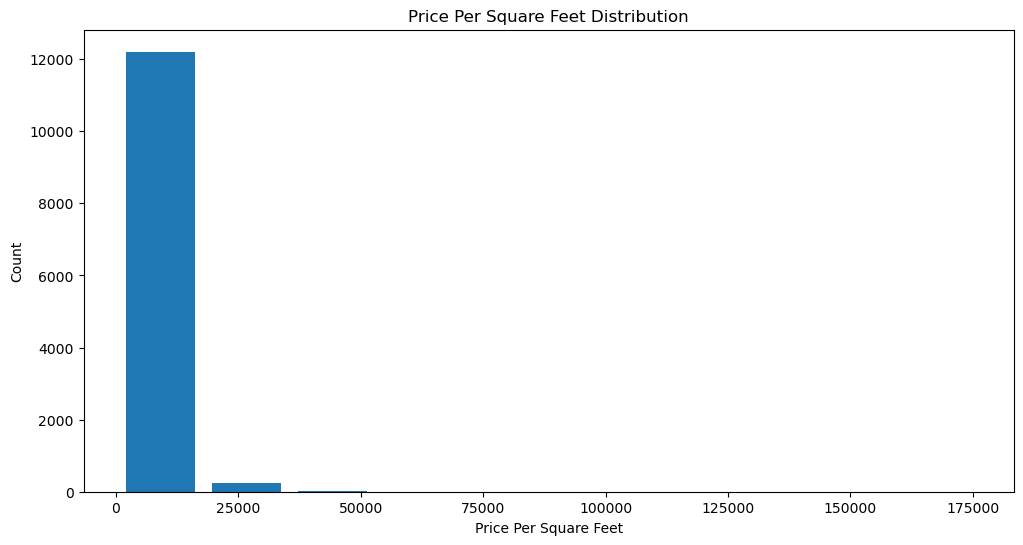

In [31]:
plt.hist(df6["price_per_sqft"], rwidth=0.8)
plt.xlabel("Price Per Square Feet")
plt.ylabel("Count")
plt.title("Price Per Square Feet Distribution")
plt.show()

## Step 25 — Check Bathroom Outliers

### What this cell does
This cell checks properties that have unusually high bathroom counts compared to BHK count.

### Why we do this
**Technical reason:**
A house with too many bathrooms compared to bedrooms may be unusual.

**Machine Learning reason:**
Unusual bathroom values can affect the regression model and reduce prediction accuracy.

In [32]:
df8 = df6.copy()
df8[df8["bath"] > df8["bhk"] + 2].head()

,area_type,location,size,total_sqft,bath,balcony,price,bhk,price_per_sqft
1078,Plot Area,BTM 1st Stage,9 Bedroom,3300.0,14.0,4.0,500.0,9,15151.515152
2620,Super built-up Area,other,6 BHK,11338.0,9.0,1.0,1000.0,6,8819.897689
6838,Super built-up Area,Rajaji Nagar,5 BHK,7500.0,8.0,3.0,1700.0,5,22666.666667
7709,Built-up Area,Chikkabanavar,4 Bedroom,2460.0,7.0,2.0,80.0,4,3252.032520
9974,Plot Area,Sector 1 HSR Layout,3 Bedroom,2400.0,6.0,2.0,775.0,3,32291.666667


## Step 26 — Remove Bathroom Outliers

### What this cell does
This cell removes properties where bathroom count is too high compared to BHK count.

### Why we do this
**Technical reason:**
We keep rows where `bath < bhk + 2`.

**Machine Learning reason:**
This removes unrealistic records and helps the model learn from more normal examples.

In [33]:
df9 = df8[df8["bath"] < df8["bhk"] + 2]
print("Shape after bathroom outlier removal:", df9.shape)

Shape after bathroom outlier removal: (12303, 9)


## Step 27 — Drop Columns Not Needed for Training

### What this cell does
This cell removes `size`.

### Why we do this
**Technical reason:**
- `size` is no longer needed because we already created `bhk`.

**Machine Learning reason:**
The model should use practical input features that we can provide when predicting a new house price.

In [34]:
df9.columns

Index(['area_type', 'location', 'size', 'total_sqft', 'bath', 'balcony',
       'price', 'bhk', 'price_per_sqft'],
      dtype='object')

In [35]:
df10 = df9.drop(["size", "price_per_sqft"], axis="columns")
df10.head()

,area_type,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,Electronic City Phase II,1056.0,2.0,1.0,39.07,2
1,Plot Area,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4
2,Built-up Area,Uttarahalli,1440.0,2.0,3.0,62.00,3
3,Super built-up Area,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3
4,Super built-up Area,Kothanur,1200.0,2.0,1.0,51.00,2


## Step 28 — Convert Categorical Columns into Numbers

### What this cell does
This cell converts `location` and `area_type` into one-hot encoded columns.

### Why we do this
**Technical reason:**
Linear Regression cannot understand text categories directly. One-hot encoding converts each category into 0/1 columns.

**Machine Learning reason:**
This allows the model to use location and area type as input features.

In [37]:
location_dummies = pd.get_dummies(df10["location"])
area_type_dummies = pd.get_dummies(df10["area_type"])

area_type_dummies.head()

,Built-up Area,Carpet Area,Plot Area,Super built-up Area
0,False,False,False,True
1,False,False,True,False
2,True,False,False,False
3,False,False,False,True
4,False,False,False,True


## Step 29 — Create the Final Model Dataset

### What this cell does
This cell joins the original numerical columns with the new one-hot encoded columns. It also removes the original text columns.

We drop the `other` location dummy column to avoid duplicate information.

### Why we do this
**Technical reason:**
The final dataset must contain only numerical columns.

**Machine Learning reason:**
This is the final form of the dataset that Linear Regression can learn from.

In [38]:
df11 = pd.concat([
    df10,
    area_type_dummies,
    location_dummies.drop("other", axis="columns")
], axis="columns")

df11 = df11.drop(["location", "area_type"], axis="columns")
df11.head()

,total_sqft,bath,balcony,price,bhk,Built-up Area,Carpet Area,Plot Area,Super built-up Area,1st Block Jayanagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,1056.0,2.0,1.0,39.07,2,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,2600.0,5.0,3.0,120.00,4,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1440.0,2.0,3.0,62.00,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1521.0,3.0,1.0,95.00,3,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,1200.0,2.0,1.0,51.00,2,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


## Step 30 — Separate Features and Target

### What this cell does
This cell separates the input features `X` and the output target `y`.

- `X` contains the columns used to predict the price.
- `y` contains the actual house price.

### Why we do this
**Technical reason:**
Scikit-learn expects input and output to be separated.

**Machine Learning reason:**
The model learns the relationship between `X` and `y`.

In [39]:
X = df11.drop("price", axis="columns")
y = df11["price"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (12303, 262)
Target shape: (12303,)


## Step 31 — Split Data into Training and Testing Sets

### What this cell does
This cell splits the data into training and testing parts.

- Training data: used to teach the model.
- Testing data: used to check how well the model performs on unseen data.

### Why we do this
**Technical reason:**
We should not test the model on the same data used for training.

**Machine Learning reason:**
Testing on unseen data gives a more honest idea of real model performance.

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=10
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 9842
Testing rows: 2461


## Step 32 — Train the Linear Regression Model

### What this cell does
This cell creates and trains a Linear Regression model.

### Why we do this
**Technical reason:**
`fit()` trains the model by finding the best linear relationship between input features and price.

**Machine Learning reason:**
The model learns how each feature affects house price. For example, it can learn that larger square feet or better locations usually increase price.

In [41]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

## Step 33 — Evaluate the Model

### What this cell does
This cell checks the model performance using the test dataset.

We calculate:
- `R² Score`: shows how well the model explains price variation. Higher is better.
- `MAE`: average absolute error. Lower is better.
- `RMSE`: larger errors are punished more. Lower is better.

### Why we do this
**Technical reason:**
Model evaluation tells us whether our model is performing well.

**Machine Learning reason:**
A trained model is not useful unless we know how accurate it is on unseen data.

In [42]:
y_pred = linear_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", round(r2, 4))
print("Mean Absolute Error:", round(mae, 4))
print("Root Mean Squared Error:", round(rmse, 4))

R2 Score: 0.4302
Mean Absolute Error: 38.8136
Root Mean Squared Error: 102.2371


## Step 34 — Compare Actual Prices and Predicted Prices

### What this cell does
This cell creates a small table comparing real prices with predicted prices.

### Why we do this
**Technical reason:**
It helps us inspect predictions in an understandable way.

**Machine Learning reason:**
Metrics are useful, but actual-vs-predicted examples help students see what the model is really doing.

In [43]:
comparison_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison_df.head(10)

,Actual Price,Predicted Price
0,57.0,79.348863
1,67.0,58.724830
2,45.0,33.855077
3,53.5,54.609002
4,82.0,58.300477
5,73.5,104.880901
6,115.0,172.519887
7,68.0,48.358673
8,68.0,121.253063
9,36.0,19.869645


## Step 35 — Create a Prediction Function

### What this cell does
This cell creates a function that predicts the price of a house using simple inputs.

Inputs:
- area type
- location
- total square feet
- number of bathrooms
- number of BHK
- number of balconies

### Why we do this
**Technical reason:**
The function converts user input into the same format used during model training.

**Machine Learning reason:**
This makes the model usable for real predictions, not only for testing.

In [44]:
def predict_price(area_type, location, total_sqft, bath, bhk, balcony):
    input_row = np.zeros(len(X.columns))
    
    input_row[0] = total_sqft
    input_row[1] = bath
    input_row[2] = balcony
    input_row[3] = bhk
    
    #[1243, 3, 1, 2, 0, 1, 0, 0,0,0,0,1,0,0,0,...... ]

    if area_type in X.columns:
        area_type_index = np.where(X.columns == area_type)[0][0]
        input_row[area_type_index] = 1
    
    if location in X.columns:
        location_index = np.where(X.columns == location)[0][0]
        input_row[location_index] = 1
    
    predicted_price = linear_model.predict([input_row])[0]
    return predicted_price

## Step 36 — Test the Prediction Function

### What this cell does
This cell tests the prediction function with one sample house.

### Why we do this
**Technical reason:**
We check whether the function works without errors.

**Machine Learning reason:**
This shows how the trained model can be used for a new house price prediction.

In [45]:
sample_prediction = predict_price(
    area_type="Super built-up  Area",
    location="Whitefield",
    total_sqft=1170,
    bath=2,
    bhk=2,
    balcony=1
)

print("Predicted price:", round(sample_prediction, 2), "lakhs")

Predicted price: 57.3 lakhs


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Step 37 — Save the Model as a Pickle File

### What this cell does
This cell saves the trained Linear Regression model and feature column names into a pickle file.

### Why we do this
**Technical reason:**
A pickle file stores Python objects. We can load this file later without training the model again.

**Machine Learning reason:**
After training a model, we usually save it so it can be used in an application, API, or future notebook.

In [46]:
model_package = {
    "model": linear_model,
    "feature_columns": list(X.columns)
}

with open("bengaluru_house_price_linear_regression_model.pickle", "wb") as file:
    pickle.dump(model_package, file)

print("Model saved as bengaluru_house_price_linear_regression_model.pickle")

Model saved as bengaluru_house_price_linear_regression_model.pickle


## Step 38 — Load the Pickle File and Test Again

### What this cell does
This cell loads the saved pickle file and checks whether the model can still be used.

### Why we do this
**Technical reason:**
Saving is useful only if we can load the file again successfully.

**Machine Learning reason:**
This simulates how we would use the model later in another notebook, website, or backend API.

In [47]:
with open("bengaluru_house_price_linear_regression_model.pickle", "rb") as file:
    loaded_package = pickle.load(file)

loaded_model = loaded_package["model"]
loaded_feature_columns = loaded_package["feature_columns"]

print("Loaded model type:", type(loaded_model))
print("Number of saved feature columns:", len(loaded_feature_columns))

Loaded model type: <class 'sklearn.linear_model._base.LinearRegression'>
Number of saved feature columns: 262


## Final Summary

In this project, we completed a full beginner-friendly Machine Learning regression workflow:

1. Loaded the dataset.
2. Explored the data.
3. Cleaned missing and invalid values.
4. Created useful features like `bhk` and `price_per_sqft`.
5. Removed major outliers.
6. Converted text columns into numerical columns using one-hot encoding.
7. Split data into training and testing sets.
8. Trained a **Linear Regression** model.
9. Evaluated the model.
10. Created a prediction function.
11. Saved the final model as a pickle file.

This notebook avoids hyperparameter tuning, GridSearchCV, advanced models, and lambda functions so students can clearly understand the main Machine Learning workflow.